# SPC Sea-Level Anomalies: Tuvalu, 1993–2023

This notebook reads the saved Pacific Data Hub / SPC SDMX CSV and prepares the
annual series used in the Rising Seas chart.

The observed series is independent of the DEM threshold scenarios.

## 1. Setup

In [1]:
import csv
import json
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np

# Portable project root: works when Jupyter is launched from the repo root
# or from the notebooks/ directory. No machine-specific absolute paths.
PROJECT_ROOT = Path("..") if Path.cwd().name == "notebooks" else Path(".")
INPUT_CSV = PROJECT_ROOT / "data" / "raw" / "official_sea_level_anomalies_tuvalu.csv"
OUTPUT_JSON = PROJECT_ROOT / "output" / "sea_level_trend.json"

print("Input CSV:", INPUT_CSV, "exists:", INPUT_CSV.exists())

Input CSV: ..\data\raw\official_sea_level_anomalies_tuvalu.csv exists: True


## 2. Read SDMX CSV

In [2]:
rows = []
with open(INPUT_CSV, encoding="utf-8") as f:
    reader = csv.DictReader(f)
    for r in reader:
        if not r.get("TIME_PERIOD") or r["OBS_VALUE"] in (None, ""):
            continue
        rows.append({"year": int(r["TIME_PERIOD"]), "value": float(r["OBS_VALUE"])})

rows.sort(key=lambda r: r["year"])
print(f"Parsed {len(rows)} data points from official CSV (expected: 31, for 1993-2023)")

Parsed 31 data points from official CSV (expected: 31, for 1993-2023)


## 3. Check annual coverage

In [3]:
expected_years = list(range(1993, 2024))
years = [r["year"] for r in rows]

assert len(rows) == 31, f"Expected 31 annual observations, found {len(rows)}"
assert len(years) == len(set(years)), "Duplicate years found in the SPC series"
assert years == expected_years, (
    "SPC annual coverage must be exactly 1993-2023 with no gaps. "
    f"Found {years[0] if years else None} to {years[-1] if years else None}."
)
assert all(np.isfinite(r["value"]) for r in rows), "Non-finite sea-level value found"

print("PASS: 31 annual observations, 1993-2023, no gaps or duplicates.")

PASS: 31 annual observations, 1993-2023, no gaps or duplicates.


## 4. Chart summary values

In [4]:
early = [r["value"] for r in rows if r["year"] <= 1997]
recent = [r["value"] for r in rows if r["year"] >= 2019]
early_avg = sum(early) / len(early)
recent_avg = sum(recent) / len(recent)
latest = rows[-1]

print(f"1993-1997 average: {early_avg:.3f}m")
print(f"2019-2023 average: {recent_avg:.3f}m")
print(f"Latest ({latest['year']}): {latest['value']}m")

1993-1997 average: 0.000m
2019-2023 average: 0.100m
Latest (2023): 0.1m


## 5. Plot

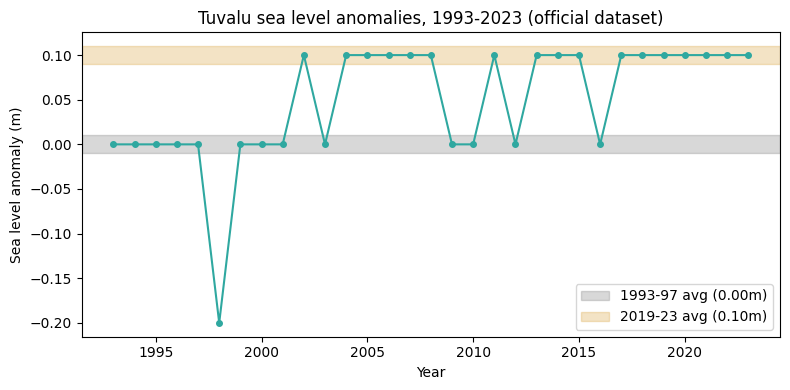

In [5]:
years = [r["year"] for r in rows]
values = [r["value"] for r in rows]

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(years, values, marker="o", color="#2FA8A0", markersize=4)
ax.axhspan(early_avg - 0.01, early_avg + 0.01, color="grey", alpha=0.3, label=f"1993-97 avg ({early_avg:.2f}m)")
ax.axhspan(recent_avg - 0.01, recent_avg + 0.01, color="#D9A441", alpha=0.3, label=f"2019-23 avg ({recent_avg:.2f}m)")
ax.set_xlabel("Year")
ax.set_ylabel("Sea level anomaly (m)")
ax.set_title("Tuvalu sea level anomalies, 1993-2023 (official dataset)")
ax.legend()
plt.tight_layout()
plt.show()

## 6. Write JSON

In [6]:
output = {
    "source": "Pacific Data Hub (SPC), DF_CLIMATE_CHANGE, Sea Level Anomalies, Tuvalu -- official Pacific Dataviz Challenge 2026 dataset",
    "raw_file": "data/raw/official_sea_level_anomalies_tuvalu.csv",
    "unit": "metres, relative to reference baseline",
    "series": rows,
    "summary": {
        "early_period": "1993-1997",
        "early_avg_m": round(early_avg, 3),
        "recent_period": "2019-2023",
        "recent_avg_m": round(recent_avg, 3),
        "latest_year": latest["year"],
        "latest_value_m": latest["value"],
    },
}

with open(OUTPUT_JSON, "w", encoding="utf-8") as f:
    json.dump(output, f, indent=2)

print(f"Saved to {OUTPUT_JSON}")

# Round-trip check: the saved JSON must contain the same annual values read
# from the raw CSV in this run.
with open(OUTPUT_JSON, encoding="utf-8") as f:
    saved = json.load(f)

assert saved["series"] == rows
print("PASS: saved JSON matches the parsed CSV series exactly.")

Saved to ..\output\sea_level_trend.json
PASS: saved JSON matches the parsed CSV series exactly.


## 7. Next step

Run `05_build_html.ipynb` after the scenario statistics and GeoJSON have been
updated.